У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score

# Завдання 1

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [51]:
# Завантажимо дані
df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/customer_segmentation_train.csv')

Спочатку на повному наборі даних здійснимо обробку пропущених значень, а далі кодування та масштабування буде здійснюватися у пайплайні

In [72]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [107]:
df['Segmentation'].value_counts()

,count
Segmentation,
D,2268
A,1972
C,1970
B,1858


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


Бачимо, що датасет має пропущені значення, які потрібно обробити. Типи даних у початковому вигляді коректні.

In [54]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


Числові дані виглядають адекватно

Перевіримо кількість пропущених значень в колонках та їх відсоток від загальної кількості записів у колонці

In [55]:
null_count = df.isnull().sum()
null_percentage = round((df.isnull().sum()/df.shape[0])*100, 2)
null_df = pd.DataFrame({'column_name' : df.columns,'null_count' : null_count,'null_percentage': null_percentage})
null_df.reset_index(drop = True, inplace = True)
null_df.sort_values(by = 'null_percentage', ascending = False)

,column_name,null_count,null_percentage
6,Work_Experience,829,10.28
8,Family_Size,335,4.15
2,Ever_Married,140,1.74
5,Profession,124,1.54
4,Graduated,78,0.97
9,Var_1,76,0.94
0,ID,0,0.00
1,Gender,0,0.00
3,Age,0,0.00
7,Spending_Score,0,0.00


### Аналіз стовпців з пропущеними значеннями

In [59]:
target_col ='Segmentation'

#### Work_Experience

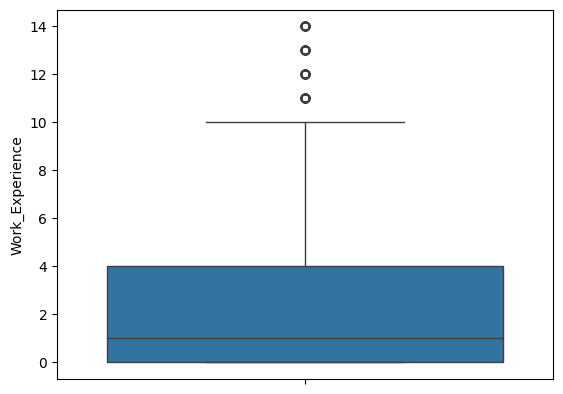

,Work_Experience
0.25,0.0
0.50,1.0
0.75,4.0
0.90,8.0
0.99,13.0
1.00,14.0


Mode: 1.0
Mean: 2.64


Work_Experience,False,True
Segmentation,,
A,0.901623,0.098377
B,0.896663,0.103337
C,0.921320,0.078680
D,0.873016,0.126984


In [149]:
sns.boxplot(df.Work_Experience)
plt.show()

display(df.Work_Experience.quantile(q = [0.25, 0.5, 0.75, 0.9, 0.99, 1]))
print('Mode:', df.Work_Experience.mode()[0])
print('Mean:', df.Work_Experience.mean().round(2))

display(pd.crosstab(df[target_col], df['Work_Experience'].isna(), normalize='index'))

На основі діаграми розмаху, значення квантилів, моди та середнього, отримані наступні результати для розподілу даних в колонці років досвіду роботи:
- медіана = 1
- мода = 1
- середнє = 2.64

Бачимо, що різниця % пропусків між класами досить помітна, отже пропуск може бути інформативним, тобто відсутність значення може вказувати на ознаку класу.

Оскільки загальний % пропусків > 10% та розподіл пропусків між класами різний, проста імпутація медіаною може спричинити заповнення пропусків в інших класах значенням, характерним для домінантного за пропусками значенням, що спричинить збій класифікації.  

Оскільки для логістичної регресії імпутація пропущених значень на етапі тренування моделі неможлива, імпутація медіаною буде здійснена в пайплайні з додаванням колонки-індикатора пропущеного значення

#### Family_Size

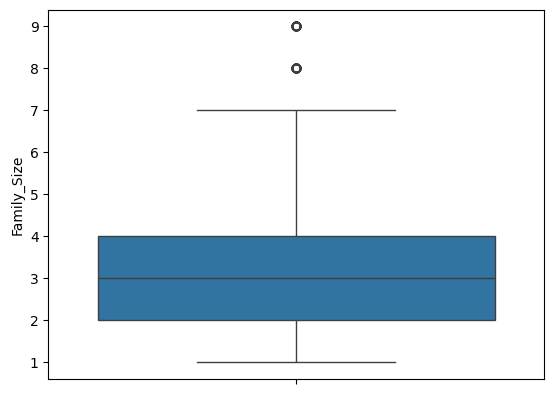

,Family_Size
0.25,2.0
0.50,3.0
0.75,4.0
0.90,5.0
0.99,8.0
1.00,9.0


Mode: 2.0
Mean: 2.85


Family_Size,False,True
Segmentation,,
A,0.951826,0.048174
B,0.976857,0.023143
C,0.977665,0.022335
D,0.932540,0.067460


In [150]:
sns.boxplot(df.Family_Size)
plt.show()

display(df.Family_Size.quantile(q = [0.25, 0.5, 0.75, 0.9, 0.99, 1]))
print('Mode:', df.Family_Size.mode()[0])
print('Mean:', df.Family_Size.mean().round(2))

display(pd.crosstab(df[target_col], df['Family_Size'].isna(), normalize='index'))

На основі діаграми розмаху, значення квантилів, моди та середнього, отримані наступні результати для розподілу даних в колонці розміру сім'ї:
- медіана = 3
- мода = 2
- середнє = 3

Розподіл пропусків між класами різний, проста імпутація медіаною може спричинити заповнення пропусків в інших класах значенням, характерним для домінантного за пропусками значенням, що спричинить збій класифікації.  

Аналогічно до попереднього стовпця, імпутація медіаною буде здійснена в пайплайні з додаванням колонки-індикатора пропущеного значення.

#### Ever_Married

In [152]:
df['Ever_Married'].value_counts()

display(pd.crosstab(df[target_col], df['Ever_Married'].isna(), normalize='index'))

Ever_Married,False,True
Segmentation,,
A,0.982759,0.017241
B,0.983315,0.016685
C,0.988325,0.011675
D,0.977072,0.022928


Розподіл пропусків між класами різний, проста імпутація може спричинити заповнення пропусків в інших класах значенням, характерним для домінантного за пропусками значенням, що спричинить збій класифікації.  

Дані в колонці категоріальні, тому для такого типу колонки можна здійснити імпутацію константою 'missing'в пайплайні з додаванням колонки-індикатора пропущеного значення.

#### Profession

In [153]:
display(df['Profession'].value_counts())

display(pd.crosstab(df[target_col], df['Profession'].isna(), normalize='index'))

,count
Profession,
Artist,2516
Healthcare,1332
Entertainment,949
Engineer,699
Doctor,688
Lawyer,623
Executive,599
Marketing,292
Homemaker,246


Profession,False,True
Segmentation,,
A,0.983266,0.016734
B,0.988159,0.011841
C,0.990863,0.009137
D,0.977513,0.022487


Розподіл пропусків між класами різний, проста імпутація може спричинити заповнення пропусків в інших класах значенням, характерним для домінантного за пропусками значенням, що спричинить збій класифікації.  

Дані в колонці категоріальні, тому для такого типу колонки можна здійснити імпутацію константою 'missing'в пайплайні з додаванням колонки-індикатора пропущеного значення.

#### Graduated

In [154]:
display(df['Graduated'].value_counts())

display(pd.crosstab(df[target_col], df['Graduated'].isna(), normalize='index'))

,count
Graduated,
Yes,4968
No,3022


Graduated,False,True
Segmentation,,
A,0.987830,0.012170
B,0.990312,0.009688
C,0.992386,0.007614
D,0.990741,0.009259


Розподіл пропусків між класами різний, проста імпутація може спричинити заповнення пропусків в інших класах значенням, характерним для домінантного за пропусками значенням, що спричинить збій класифікації.  

Дані в колонці категоріальні, тому для такого типу колонки можна здійснити імпутацію константою 'missing'в пайплайні з додаванням колонки-індикатора пропущеного значення.

#### Var_1

In [155]:
display(df['Var_1'].value_counts())

display(pd.crosstab(df[target_col], df['Var_1'].isna(), normalize='index'))

,count
Var_1,
Cat_6,5238
Cat_4,1089
Cat_3,822
Cat_2,422
Cat_7,203
Cat_1,133
Cat_5,85


Var_1,False,True
Segmentation,,
A,0.990365,0.009635
B,0.993003,0.006997
C,0.989340,0.010660
D,0.989859,0.010141


Розподіл пропусків між класами різний, проста імпутація може спричинити заповнення пропусків в інших класах значенням, характерним для домінантного за пропусками значенням, що спричинить збій класифікації.  

Дані в колонці категоріальні, тому для такого типу колонки можна здійснити імпутацію константою 'missing'в пайплайні з додаванням колонки-індикатора пропущеного значення.

### Обробка пропущених значень, кодування та масштабування даних у пайплайні

Для обробки пропущених значень в пайплайні буде окрема імпутація числових та категоріальних колонок з додаванням колонки-індикатора пропущених значень.

Для числових даних буде здійснено масштабування за допомогою MinMaxScaler, для категоріальних - кодування з відкиданням однієї колонки для уникнення мультиколінеарності.

Також для тренування моделі не потрібна колонка з id клієнта, тому колонка не буде включена до input_cols

In [112]:
# Target column
target_col = 'Segmentation'

# Create training and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df[[target_col]])

# Create inputs and targets
input_cols = [col for col in df.columns[1:-1]]
train_inputs, train_targets = train_df[input_cols], train_df[target_col]
test_inputs, test_targets = test_df[input_cols], test_df[target_col]

# Encoding targets separately
label_encoder = LabelEncoder()
train_targets_encoded = label_encoder.fit_transform(train_targets)
test_targets_encoded = label_encoder.transform(test_targets)

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('cat_imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [116]:
X_train = preprocessor.fit_transform(train_inputs)
y_train = train_targets_encoded
X_test = preprocessor.transform(test_inputs)
y_test = test_targets_encoded

# Завдання 2

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [104]:
feat = preprocessor.get_feature_names_out()
cat_idx = [i for i, n in enumerate(feat) if n.startswith('cat__')]

## Числові ознаки

In [138]:
# Знаходимо порядкові індекси числових колонок у вихідному X_train
num_idx = [i for i, n in enumerate(feat) if n.startswith('num__')]

# Відбираємо з X_train тільки ці колонки
X_train_num = X_train[:, num_idx]

In [141]:
# SMOTE на НЕкатегоріальних ознаках
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_num, y_train)

# SMOTE-Tomek на НЕкатегоріальних ознаках
smote_tomek = SMOTETomek(random_state=42)
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train_num, y_train)

## Числові + категоріальні ознаки

In [142]:
# SMOTENC
smotenc = SMOTENC(categorical_features=cat_idx, random_state=42)
X_train_smotenc, y_train_smotenc = smotenc.fit_resample(X_train, y_train)

In [143]:
# SMOTE-Tomek
# Використаємо комбінацію не зі звичайним SMOTE, а з SMOTENC
smotenc_tomek = SMOTETomek(smote=smotenc, random_state=42)
X_train_smotenc_tomek, y_train_smotenc_tomek = smotenc_tomek.fit_resample(X_train, y_train)

# Завдання 3

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

Для тренування моделі використаємо дані, отримані після ресамплінгу із застосуванням методів SMOTENC та SMOTENC-Tomek

In [148]:
# Оголошуємо 3 моделі - для кожного з наборів даних
model_original = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))
model_smotenc = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))
model_smotenc_tomek = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))

# Навчаємо кожну модель на своєму наборі даних
model_original.fit(X_train, y_train)
model_smotenc.fit(X_train_smotenc, y_train_smotenc)
model_smotenc_tomek.fit(X_train_smotenc_tomek, y_train_smotenc_tomek)

models = {
    "Original Data": model_original,
    "SMOTENС Data": model_smotenc,
    "SMOTENС-Tomek Data": model_smotenc_tomek
}

for name, model in models.items():
    print(f"\n Метрики для: {name}")
    preds = model.predict(X_test)
    print(classification_report(y_test, preds, target_names=label_encoder.classes_))


 Метрики для: Original Data
              precision    recall  f1-score   support

           A       0.42      0.46      0.44       394
           B       0.36      0.16      0.22       372
           C       0.49      0.62      0.55       394
           D       0.66      0.76      0.70       454

    accuracy                           0.51      1614
   macro avg       0.48      0.50      0.48      1614
weighted avg       0.49      0.51      0.49      1614


 Метрики для: SMOTENС Data
              precision    recall  f1-score   support

           A       0.41      0.47      0.44       394
           B       0.38      0.24      0.29       372
           C       0.52      0.60      0.56       394
           D       0.67      0.71      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.50      1614
weighted avg       0.50      0.52      0.51      1614


 Метрики для: SMOTENС-Tomek Data
              precision    recall  f1-s

Для порівняння моделей між собою основною метрикою оберемо F1-Score.   

Найкращі показники як  macro avg так і weighted avg для моделі з ресамплінгом SMOTENC, проте великої різниці між цією моделлю та SMOTENС-Tomek та оригінальними даними немає.

Імовірна причина невеликої різниці якості моделей може бути в тому, що кількість екземплярів кожного класу приблизно однакова, і при поділі даних на тренувальний та тестовий набори ця пропорційність збереглася завдяки параметру `stratify=df[[target_col]]`
і тому дибалансу класів не виникло.

In [156]:
df['Segmentation'].value_counts()

,count
Segmentation,
D,2268
A,1972
C,1970
B,1858
